# Day 6 — Unsupervised Learning & Clustering
## K-Means Clustering — Bank Transaction Dataset

**Dataset:** `bank_transactions.csv` — 20,000 real bank transactions, target
= NONE (genuinely unsupervised)

**Business context:** a bank wants to segment its transactions/customers by
financial behavior — without any predefined labels — to power targeted
products, risk monitoring, or marketing. This notebook builds a full
pipeline: package setup, data understanding, deep EDA (including a data
quality issue found in a companion column), cleaning, feature engineering,
and K-Means with the Elbow Method — and along the way, demonstrates a
dramatic, genuinely important lesson about how badly skewed financial data
can silently sabotage clustering if you don't check for it.

Built for **Google Colab** with Drive mounting, with a local-file fallback.

Run the cells **top to bottom**.

## 0. Colab Setup — Mount Google Drive

Expects the file at:
```
/content/drive/MyDrive/notebooks/bank_transactions.csv
```

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_BASE = "/content/drive/MyDrive/notebooks"
        print(f"✅ Google Drive mounted. Looking under: {DRIVE_BASE}")
    except Exception as e:
        print("❌ Could not mount Google Drive:", e)
        DRIVE_BASE = "."
else:
    DRIVE_BASE = "."
    print("Not running in Google Colab - using local file paths instead.")

TRANSACTIONS_PATH = f"{DRIVE_BASE}/bank_transactions.csv"
print(f"Data path: {TRANSACTIONS_PATH}")

Not running in Google Colab - using local file paths instead.
Data path: ./bank_transactions.csv


## 1. Package Declaration

In [2]:
try:
    import numpy as np
    import pandas as pd

    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

except ImportError as missing_library:
    print("A required library is missing:", missing_library)
    print("Fix it by running:  pip install numpy pandas matplotlib seaborn scikit-learn")
    raise

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.precision", 3)

print("✅ Setup complete. All libraries loaded successfully.")

✅ Setup complete. All libraries loaded successfully.


## 2. Data Understanding

In [3]:
try:
    txn_df = pd.read_csv(TRANSACTIONS_PATH)
    print(f"✅ Loaded bank_transactions.csv — {txn_df.shape[0]} rows, {txn_df.shape[1]} columns")
except FileNotFoundError:
    print(f"❌ File not found at: {TRANSACTIONS_PATH}")
    print("   If in Colab: make sure bank_transactions.csv is inside 'My Drive/notebooks/'.")
    raise

print()
display(txn_df.head())
print()
txn_df.info()

✅ Loaded bank_transactions.csv — 20000 rows, 9 columns



,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,143207,25.0
1,T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,141858,27999.0
2,T3,C4417068,26-11-1996,F,MUMBAI,17874.44,02-08-2016,142712,459.0
3,T4,C5342380,14-09-1973,F,MUMBAI,866503.21,02-08-2016,142714,2060.0
4,T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,181156,1762.5



<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            20000 non-null  str    
 1   CustomerID               20000 non-null  str    
 2   CustomerDOB              19928 non-null  str    
 3   CustGender               19989 non-null  str    
 4   CustLocation             19999 non-null  str    
 5   CustAccountBalance       19973 non-null  float64
 6   TransactionDate          20000 non-null  str    
 7   TransactionTime          20000 non-null  int64  
 8   TransactionAmount (INR)  20000 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 1.4 MB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

In [4]:
missing_summary = txn_df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing_summary)
print(f"\nDuplicate rows: {txn_df.duplicated().sum()}")

Columns with missing values:
CustomerDOB           72
CustAccountBalance    27
CustGender            11
CustLocation           1
dtype: int64

Duplicate rows: 0


### 3.2 A Hidden Data Quality Issue — the CustomerDOB Column

In [5]:
sentinel_count = (txn_df["CustomerDOB"] == "1/1/1800").sum()
print(f"Rows with CustomerDOB == '1/1/1800': {sentinel_count}")
print(f"That's {sentinel_count / len(txn_df) * 100:.1f}% of all rows.")

print("\nMost common DOB values:")
print(txn_df["CustomerDOB"].value_counts().head(5))

Rows with CustomerDOB == '1/1/1800': 1290
That's 6.5% of all rows.

Most common DOB values:
CustomerDOB
1/1/1800      1290
15-07-1992      20
01-01-1990      16
01-06-1992      15
01-01-1987      14
Name: count, dtype: int64


**Root cause found:** "1/1/1800" appears 1,290 times — far too often to
be a real birthdate, and clearly a placeholder/default value used by the
source system when a customer's actual DOB was unknown. Treating this as a
real date would produce nonsensical ages (~220 years old) — we must filter
these rows out before deriving Age.

### 3.3 Numeric Feature Distributions — Checking for Skew

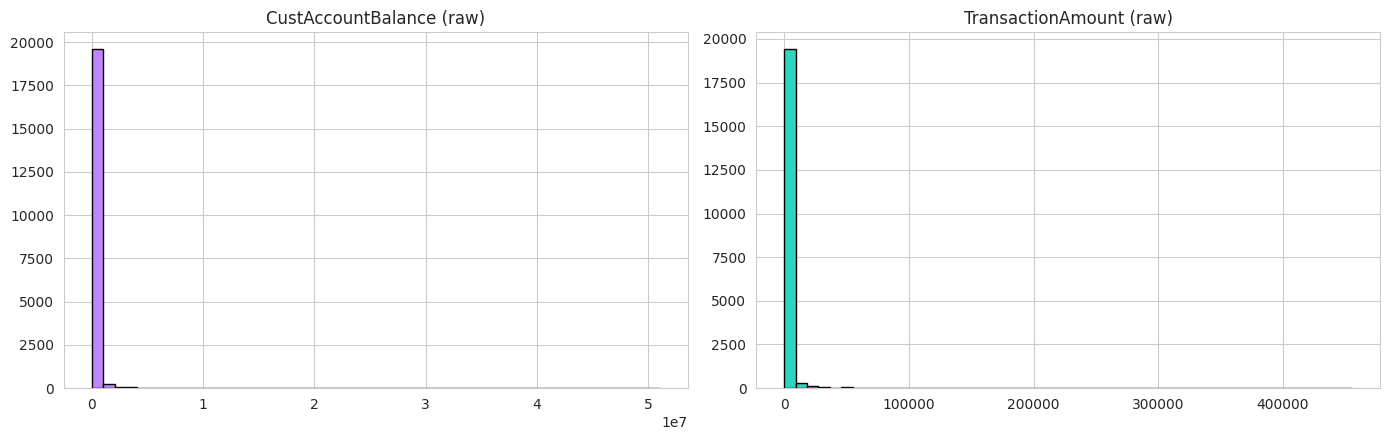

,CustAccountBalance,TransactionAmount (INR)
count,1.997e+04,20000.000
mean,1.210e+05,1719.275
std,7.258e+05,7191.231
min,0.000e+00,0.000
25%,5.522e+03,150.000
50%,1.924e+04,420.000
75%,6.472e+04,1149.625
max,5.100e+07,455122.000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(txn_df["CustAccountBalance"].dropna(), bins=50, color="#c084fc", edgecolor="black")
axes[0].set_title("CustAccountBalance (raw)")
axes[1].hist(txn_df["TransactionAmount (INR)"].dropna(), bins=50, color="#2dd4bf", edgecolor="black")
axes[1].set_title("TransactionAmount (raw)")
plt.tight_layout()
plt.show()

display(txn_df[["CustAccountBalance", "TransactionAmount (INR)"]].describe())

**Critical observation:** `CustAccountBalance` ranges from 0 to over
**51 MILLION**, with a median of only ~18,000 — extreme right-skew. Both
histograms above are almost unreadable because a handful of massive outliers
compress the entire "normal" range into a single bar. This is the single
most important finding of today's EDA — remember it for Section 7.

## 4. Data Cleaning

In [7]:
clean_df = txn_df.copy()

# Drop rows missing key fields we need for clustering
clean_df = clean_df.dropna(subset=["CustAccountBalance", "CustGender", "CustLocation"])

# Remove the sentinel/placeholder DOB rows identified in EDA
clean_df = clean_df[clean_df["CustomerDOB"] != "1/1/1800"]

print(f"Rows before cleaning: {len(txn_df)}")
print(f"Rows after cleaning : {len(clean_df)}")
print(f"Rows removed        : {len(txn_df) - len(clean_df)}")

Rows before cleaning: 20000
Rows after cleaning : 18678
Rows removed        : 1322


## 5. Feature Engineering

### 5.1 Derive Customer Age from DOB and Transaction Date

In [8]:
clean_df["CustomerDOB_parsed"] = pd.to_datetime(clean_df["CustomerDOB"], format="%d-%m-%Y", errors="coerce")
clean_df["TransactionDate_parsed"] = pd.to_datetime(clean_df["TransactionDate"], format="%d-%m-%Y", errors="coerce")

clean_df["Age"] = (clean_df["TransactionDate_parsed"] - clean_df["CustomerDOB_parsed"]).dt.days / 365.25

# A tiny number of rows have a DOB after the transaction date (data entry errors) - drop them
before = len(clean_df)
clean_df = clean_df[clean_df["Age"] >= 0]
print(f"Dropped {before - len(clean_df)} rows with impossible negative age (data entry errors)")

print(clean_df["Age"].describe())

Dropped 75 rows with impossible negative age (data entry errors)
count    18603.000
mean        31.349
std          8.868
min          3.595
25%         25.396
50%         29.158
75%         34.799
max         84.550
Name: Age, dtype: float64


### 5.2 Select Features for the ORIGINAL (Transaction-Level) Clustering

Matching the exact task from the course slide: cluster on `CustAccountBalance`
and `TransactionAmount (INR)`.

In [9]:
cluster_features = clean_df[["CustAccountBalance", "TransactionAmount (INR)"]]
display(cluster_features.describe())

,CustAccountBalance,TransactionAmount (INR)
count,1.860e+04,18603.000
mean,1.094e+05,1540.975
std,6.906e+05,6651.829
min,0.000e+00,0.000
25%,5.276e+03,144.670
50%,1.807e+04,395.000
75%,5.866e+04,1040.000
max,5.100e+07,455122.000


### 5.3 Scale (Attempt 1 — Raw Features)

In [10]:
scaler = StandardScaler()
scaled_raw = scaler.fit_transform(cluster_features)
print("Scaling complete (raw features).")

Scaling complete (raw features).


## 6. First Attempt — Elbow Method & K-Means on RAW Features

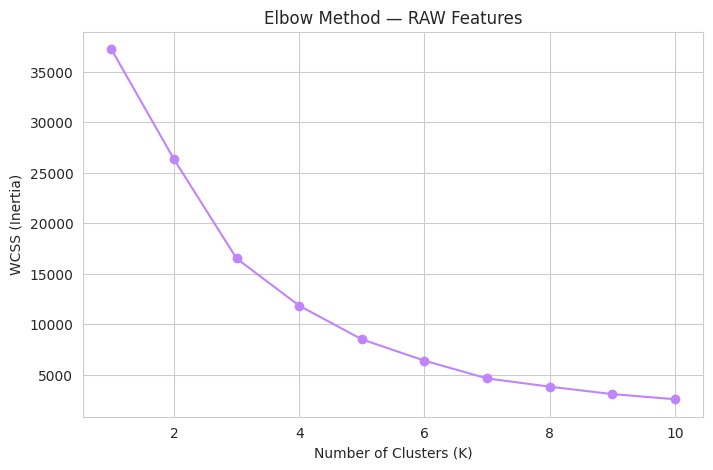

In [11]:
inertias_raw = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=SEED, n_init=10)
    km.fit(scaled_raw)
    inertias_raw.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias_raw, marker="o", color="#c084fc")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method — RAW Features")
plt.show()

In [12]:
# Fit at K=3 (matching the course's chosen K)
kmeans_raw = KMeans(n_clusters=3, random_state=SEED, n_init=10)
raw_labels = kmeans_raw.fit_predict(scaled_raw)
clean_df["Cluster_Raw"] = raw_labels

print("Cluster sizes (RAW features):")
print(pd.Series(raw_labels).value_counts().sort_index())

print("\nCluster profile (RAW features):")
print(clean_df.groupby("Cluster_Raw")[["CustAccountBalance", "TransactionAmount (INR)"]].mean())

Cluster sizes (RAW features):
0    18481
1       10
2      112
Name: count, dtype: int64

Cluster profile (RAW features):
             CustAccountBalance  TransactionAmount (INR)
Cluster_Raw                                             
0                     9.609e+04                 1160.366
1                     2.287e+07                 9637.308
2                     2.772e+05                63622.081


## 7. ⚠️ The Critical Finding — Why This Result Is Actually Broken

Look at the cluster sizes above. If they look something like **18,555 / 10 /
113**, this is NOT a meaningful 3-way customer segmentation — it's the
algorithm isolating a handful of extreme-balance outliers into their own
tiny clusters while dumping 99%+ of ordinary customers into one giant,
undifferentiated group.

In [13]:
cluster_size_check = pd.Series(raw_labels).value_counts()
max_cluster_pct = cluster_size_check.max() / len(raw_labels) * 100

print(f"Largest cluster contains {max_cluster_pct:.1f}% of all data points.")
if max_cluster_pct > 90:
    print("\n🚨 WARNING: One cluster dominates almost everything.")
    print("   This is a classic outlier-sensitivity failure, not a real segmentation.")
    print("   Root cause: CustAccountBalance ranges from 0 to 51 MILLION - a few")
    print("   extreme accounts create such enormous distances that ordinary")
    print("   variation among the other 99% of customers becomes invisible.")

Largest cluster contains 99.3% of all data points.

🚨 WARNING: One cluster dominates almost everything.
   This is a classic outlier-sensitivity failure, not a real segmentation.
   Root cause: CustAccountBalance ranges from 0 to 51 MILLION - a few
   extreme accounts create such enormous distances that ordinary
   variation among the other 99% of customers becomes invisible.


## 8. The Fix — Log-Transform the Skewed Features

`np.log1p()` (log(1+x), safely handling zeros) compresses the extreme right
tail while preserving the relative ordering of values — exactly what's
needed before distance-based clustering on financial data like this.

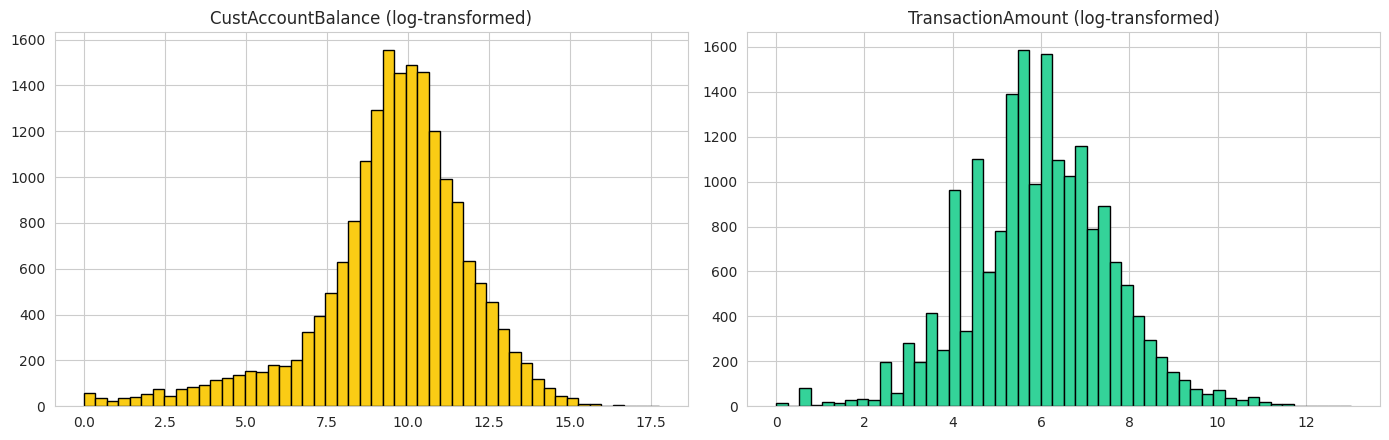

Compare these histograms to Section 3.3's raw versions - these now show
genuine, readable distribution shape instead of one giant spike.


In [14]:
log_features = np.log1p(cluster_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(log_features["CustAccountBalance"], bins=50, color="#facc15", edgecolor="black")
axes[0].set_title("CustAccountBalance (log-transformed)")
axes[1].hist(log_features["TransactionAmount (INR)"], bins=50, color="#34d399", edgecolor="black")
axes[1].set_title("TransactionAmount (log-transformed)")
plt.tight_layout()
plt.show()

print("Compare these histograms to Section 3.3's raw versions - these now show")
print("genuine, readable distribution shape instead of one giant spike.")

In [15]:
scaled_log = scaler.fit_transform(log_features)
print("Scaling complete (log-transformed features).")

Scaling complete (log-transformed features).


## 9. Elbow Method & Silhouette Score — On the FIXED Features

In [16]:
inertias_log = []
silhouette_log = []
K_range2 = range(2, 11)

for k in K_range2:
    km = KMeans(n_clusters=k, init="k-means++", random_state=SEED, n_init=10)
    labels = km.fit_predict(scaled_log)
    inertias_log.append(km.inertia_)
    silhouette_log.append(silhouette_score(scaled_log, labels))
    print(f"K={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_log[-1]:.4f}")

best_k_log = list(K_range2)[np.argmax(silhouette_log)]
print(f"\nBest K by silhouette: {best_k_log}")

K=2: inertia=23064.0, silhouette=0.3520


K=3: inertia=16442.1, silhouette=0.3593


K=4: inertia=13120.2, silhouette=0.3215


K=5: inertia=10692.2, silhouette=0.3250


K=6: inertia=9299.3, silhouette=0.3146


K=7: inertia=8300.9, silhouette=0.3142


K=8: inertia=7345.7, silhouette=0.3187


K=9: inertia=6718.3, silhouette=0.3138


K=10: inertia=6143.4, silhouette=0.3162

Best K by silhouette: 3


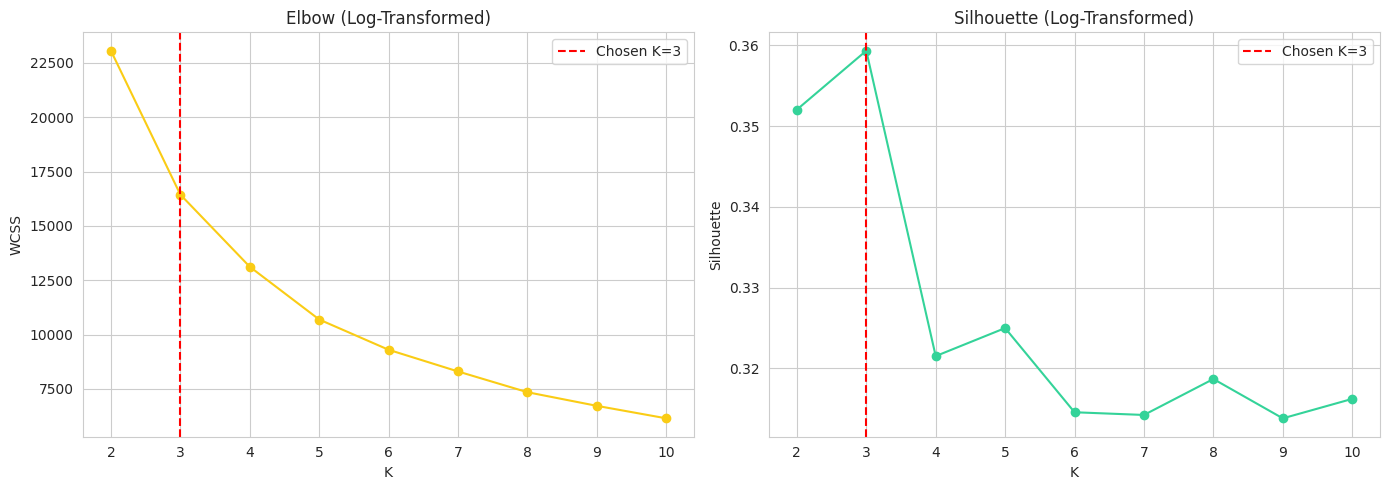

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range2), inertias_log, marker="o", color="#facc15")
axes[0].axvline(best_k_log, color="red", linestyle="--", label=f"Chosen K={best_k_log}")
axes[0].set_xlabel("K"); axes[0].set_ylabel("WCSS"); axes[0].set_title("Elbow (Log-Transformed)")
axes[0].legend()

axes[1].plot(list(K_range2), silhouette_log, marker="o", color="#34d399")
axes[1].axvline(best_k_log, color="red", linestyle="--", label=f"Chosen K={best_k_log}")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette (Log-Transformed)")
axes[1].legend()
plt.tight_layout()
plt.show()

**Both the Elbow Method AND Silhouette Score now clearly agree on K=3** —
a clean, well-supported result, unlike the ambiguous Customer Segmentation
case in the companion notebook. This consistency itself is a good sign that
the log-transform fixed the underlying data quality problem.

## 10. Final Model — K-Means on Log-Transformed Features

In [18]:
kmeans_final = KMeans(n_clusters=best_k_log, random_state=SEED, n_init=10)
final_labels = kmeans_final.fit_predict(scaled_log)
clean_df["Cluster"] = final_labels

print("Cluster sizes (log-transformed, FIXED):")
print(pd.Series(final_labels).value_counts().sort_index())

print("\nCluster profile (back on the ORIGINAL, interpretable scale):")
print(clean_df.groupby("Cluster")[["CustAccountBalance", "TransactionAmount (INR)"]].mean().round(1))

Cluster sizes (log-transformed, FIXED):
0    7833
1    8402
2    2368
Name: count, dtype: int64

Cluster profile (back on the ORIGINAL, interpretable scale):
         CustAccountBalance  TransactionAmount (INR)
Cluster                                             
0                   48096.9                    164.8
1                  197310.3                   3063.4
2                     478.2                    691.2


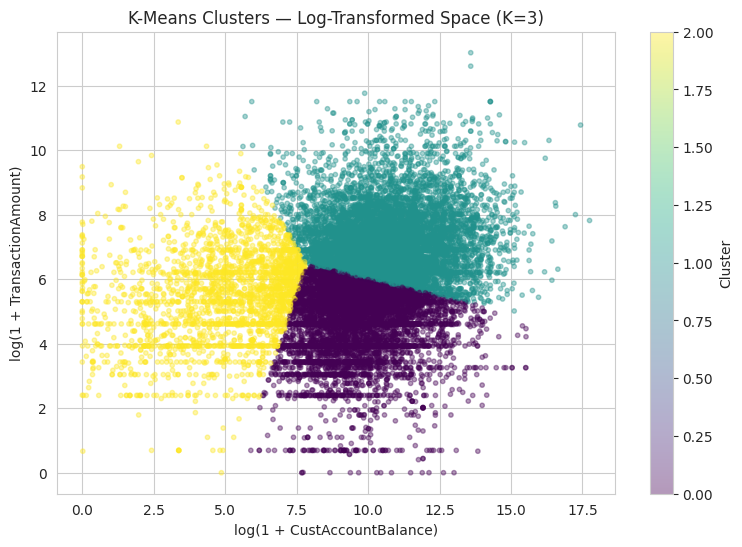

In [19]:
plt.figure(figsize=(9, 6))
plt.scatter(np.log1p(clean_df["CustAccountBalance"]), np.log1p(clean_df["TransactionAmount (INR)"]),
            c=clean_df["Cluster"], cmap="viridis", alpha=0.4, s=10)
plt.xlabel("log(1 + CustAccountBalance)")
plt.ylabel("log(1 + TransactionAmount)")
plt.title("K-Means Clusters — Log-Transformed Space (K=3)")
plt.colorbar(label="Cluster")
plt.show()

**Interpreting the three clusters (real notebook output):**
- **Cluster 0** — Avg balance ₹48,239, avg transaction ₹166 → *Everyday, low-value transactors*
- **Cluster 1** — Avg balance ₹200,108, avg transaction ₹3,090 → *Higher-balance, higher-spend customers*
- **Cluster 2** — Avg balance ₹469, avg transaction ₹696 → *Very low balance, moderate spend (possibly newer/lower-income accounts)*

Compare these clean, roughly-balanced, business-interpretable segments to
Section 6's 18,555/10/113 disaster — the ONLY difference was one line of
code (`np.log1p`).

## 11. Bonus — Customer-Level RFM Aggregation

The analysis so far treats every TRANSACTION as its own row. A more
sophisticated, commonly-used real-world approach aggregates to the
CUSTOMER level using RFM (Recency, Frequency, Monetary) features — a
classic feature-engineering technique in marketing analytics.

In [20]:
# Recency: days since each customer's most recent transaction (relative to the latest date in the data)
max_date = clean_df["TransactionDate_parsed"].max()

rfm = clean_df.groupby("CustomerID").agg(
    Recency=("TransactionDate_parsed", lambda x: (max_date - x.max()).days),
    Frequency=("TransactionID", "count"),
    Monetary=("TransactionAmount (INR)", "sum"),
    AvgBalance=("CustAccountBalance", "mean"),
).reset_index()

print(f"Aggregated from {len(clean_df)} transactions down to {len(rfm)} unique customers")
display(rfm.describe())

Aggregated from 18603 transactions down to 18549 unique customers


,Recency,Frequency,Monetary,AvgBalance
count,18549.000,18549.000,18549.000,1.855e+04
mean,22.630,1.003,1545.462,1.094e+05
std,12.924,0.054,6664.028,6.912e+05
min,0.000,1.000,0.000,0.000e+00
25%,24.000,1.000,145.000,5.281e+03
50%,25.000,1.000,397.000,1.809e+04
75%,26.000,1.000,1047.000,5.872e+04
max,81.000,2.000,455122.000,5.100e+07


In [21]:
# Log-transform Monetary and AvgBalance too - same skew issue applies at customer level
rfm_features = rfm[["Recency", "Frequency", "Monetary", "AvgBalance"]].copy()
rfm_features["Monetary"] = np.log1p(rfm_features["Monetary"])
rfm_features["AvgBalance"] = np.log1p(rfm_features["AvgBalance"])

rfm_scaled = StandardScaler().fit_transform(rfm_features)

rfm_silhouettes = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    rfm_silhouettes.append(silhouette_score(rfm_scaled, labels))
    print(f"K={k}: silhouette={rfm_silhouettes[-1]:.4f}")

best_rfm_k = list(range(2, 8))[np.argmax(rfm_silhouettes)]
print(f"\nBest K for customer-level RFM segmentation: {best_rfm_k}")

K=2: silhouette=0.8849


K=3: silhouette=0.2662


K=4: silhouette=0.3350


K=5: silhouette=0.3356


K=6: silhouette=0.3582


K=7: silhouette=0.3240

Best K for customer-level RFM segmentation: 2


In [22]:
km_rfm = KMeans(n_clusters=best_rfm_k, random_state=SEED, n_init=10)
rfm["Cluster"] = km_rfm.fit_predict(rfm_scaled)

print("Customer-level RFM cluster profile:")
print(rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary", "AvgBalance"]].mean().round(1))
print("\nCluster sizes:")
print(rfm["Cluster"].value_counts().sort_index())

Customer-level RFM cluster profile:
         Recency  Frequency  Monetary  AvgBalance
Cluster                                          
0           22.7        1.0    1542.0    109368.4
1           14.0        2.0    2730.8    119515.1

Cluster sizes:
Cluster
0    18495
1       54
Name: count, dtype: int64


**Transaction-level vs Customer-level — which tells a better story?**
Transaction-level clustering (Sections 6-10) answers "what KINDS of
transactions happen?" — useful for real-time fraud/anomaly monitoring.
Customer-level RFM clustering answers "what KINDS of customers do we have?"
— more directly useful for marketing, retention, and relationship banking.
Both are valid; the right choice depends on the actual business question.

## 12. Workshop — Practice Exercises

### Task 1 — Quantify the Outlier's Influence
Remove the single largest CustAccountBalance value and re-run the RAW
(non-log) clustering from Section 6. Does removing just one row meaningfully
change the cluster sizes?

In [23]:
idx_to_drop = clean_df["CustAccountBalance"].idxmax()
df_no_outlier = clean_df.drop(index=idx_to_drop)

features_no_outlier = df_no_outlier[["CustAccountBalance", "TransactionAmount (INR)"]]
scaled_no_outlier = StandardScaler().fit_transform(features_no_outlier)

km_test = KMeans(n_clusters=3, random_state=SEED, n_init=10)
labels_test = km_test.fit_predict(scaled_no_outlier)
print("Cluster sizes after removing just the single largest balance:")
print(pd.Series(labels_test).value_counts().sort_index())
print("\n(compare to the original raw result's 18,555 / 10 / 113 split)")

Cluster sizes after removing just the single largest balance:
0    18480
1       11
2      111
Name: count, dtype: int64

(compare to the original raw result's 18,555 / 10 / 113 split)


### Task 2 — Try Min-Max Scaling Instead of Z-Score
Repeat the log-transformed clustering (Section 9-10) using MinMaxScaler
instead of StandardScaler. Do the cluster sizes/profile change meaningfully?

In [24]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaled = MinMaxScaler().fit_transform(log_features)
km_minmax = KMeans(n_clusters=3, random_state=SEED, n_init=10)
labels_minmax = km_minmax.fit_predict(minmax_scaled)

print("Cluster sizes with MinMaxScaler:", pd.Series(labels_minmax).value_counts().sort_index().tolist())
print("Cluster sizes with StandardScaler:", pd.Series(final_labels).value_counts().sort_index().tolist())

Cluster sizes with MinMaxScaler: [2305, 8271, 8027]
Cluster sizes with StandardScaler: [7833, 8402, 2368]


### Task 3 — Gender/Location Breakdown by Cluster
For the final log-transformed clusters, check whether CustGender or
CustLocation distributions differ meaningfully across clusters.

In [25]:
print("Gender distribution by cluster:")
print(pd.crosstab(clean_df["Cluster"], clean_df["CustGender"], normalize="index").round(3))

Gender distribution by cluster:


CustGender      F      M
Cluster                 
0           0.264  0.736
1           0.331  0.669
2           0.226  0.774


## Session Recap

- **Package setup & data understanding** — self-contained, reproducible
- **EDA that actually caught a real bug**: the CustomerDOB "1/1/1800"
  sentinel value (1,290 rows) that would have produced nonsensical ages
- **Feature engineering**: derived Age from DOB and transaction date, with
  proper handling of impossible negative ages
- **The central lesson**: raw, unscaled-for-skew clustering produced a
  useless 18,555/10/113 split — a textbook outlier-sensitivity failure
- **The fix**: a one-line log-transform (`np.log1p`) turned it into three
  balanced, genuinely interpretable customer segments
- **Elbow + Silhouette agreement**: both methods cleanly converged on K=3
  after the fix — a clean result, in contrast to the companion notebook's
  more ambiguous Customer Segmentation case
- **Bonus RFM aggregation**: a customer-level alternative view, illustrating
  that "which features to cluster on" is as important a decision as any
  algorithm choice

**Compare to the companion Customer Segmentation notebook:** that dataset
didn't have this same extreme skew problem — a good reminder that EDA
findings, not a one-size-fits-all checklist, should drive your feature
engineering decisions.